In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid
from torchcodec.encoders import VideoEncoder

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../')

In [2]:
import os
import time
import warnings
import datetime
from pathlib import Path
from typing import Any, Callable, Optional, Union, cast

import torch
import torch.nn as nn

import torchvision
from torchvision import tv_tensors
from torchvision.transforms import v2
from torch.utils.data import DataLoader, default_collate

import numpy as np

%load_ext autoreload
%autoreload 2

from computer_vision.torch_video.data.sampler import RandomClipSampler, UniformClipSampler
from computer_vision.torch_video.data.dataset import UCF101, ConvertTCHWtoCTHW, DATA_MEAN, DATA_STD, NUM_CLASSES
from computer_vision.torch_video.parameter_parser import parser

from computer_vision.torch_video.utils.progress import MetricLogger, form_stats, save_metrics
from computer_vision.torch_video.utils.train_utils import evaluate, train_one_epoch
from computer_vision.torch_video.utils.torch_utils import init_seeds, seed_worker, init_distributed_mode, initialize_weights,\
reduce_across_processes, save_checkpoint
from computer_vision.torch_video.utils.plotting import plot_results

In [3]:
data_dirpath=Path('D:/data/UCF101')
root=data_dirpath/'UCF-101'
annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask'
output_dirpath=Path('D:/results/ucf101/train')
metadata_path=data_dirpath/'metadata.pt'
class_id_path=annotation_path/"classInd.txt"
allowed_time=10/60

arguments= f"""-d {root} -a {annotation_path} -m {metadata_path} -o {output_dirpath} -c {class_id_path}
--data-fold 1 --frame-rate 8 --clip-duration 2 --step-duration 1.7 
--device cpu --use-cutmix-mixup --time {allowed_time} --n-batches 4 --epochs 2
"""
args=parser.parse_args(arguments.split())


In [4]:
args.start_training_time=time.time() # time at the start of training program
args.ouput_path=Path(args.ouput_path)
args.ouput_path.mkdir(parents=True, exist_ok=True)
args.checkpoint_dirpath=args.ouput_path/"checkpoint"
args.checkpoint_dirpath.mkdir(parents=True, exist_ok=True)

init_distributed_mode(args)

device=(torch.device(args.device) 
        if (args.device=='cuda' and torch.cuda.is_available() and torch.cuda.device_count()>0) 
        else torch.device('cpu') )

init_seeds(args.seed+1,deterministic=args.use_deterministic_algorithms)

# Data loader
train_dataset=UCF101(root=args.data_path, annotation_path=args.annotation_path, frame_rate=args.frame_rate, 
                     clip_duration=args.clip_duration, step_duration=args.step_duration,
                     train=True, metadata_path=args.metadata_path, fold=args.data_fold, sampling_type='random', use_audio=False,
                     decoder_transforms=[v2.RandomCrop(size=args.train_crop_size),
                                         v2.Resize(args.train_resize_size)],
                     transforms=v2.Compose([
                         v2.RandomHorizontalFlip(p=args.hflip_prob),
                         v2.ToDtype(torch.float32, scale=True),
                         v2.Normalize(mean=DATA_MEAN,std=DATA_STD),
                         ConvertTCHWtoCTHW()])
                    ) 

val_dataset=UCF101(root=args.data_path, annotation_path=args.annotation_path, frame_rate=args.frame_rate, 
                     clip_duration=args.clip_duration, step_duration=args.step_duration,
                     train=False, metadata_path=args.metadata_path, fold=args.data_fold, sampling_type='regular', use_audio=False,
                     decoder_transforms=[v2.CenterCrop(size=args.train_crop_size),
                                         v2.Resize(args.train_resize_size)],
                     transforms=v2.Compose([
                         v2.ToDtype(torch.float32, scale=True),
                         v2.Normalize(mean=DATA_MEAN,std=DATA_STD),
                         ConvertTCHWtoCTHW()])
                    ) 

if args.use_cutmix_mixup:
    cutmix=v2.CutMix(num_classes=NUM_CLASSES, alpha=args.cutmix_alpha)
    mixup=v2.MixUp(num_classes=NUM_CLASSES, alpha=args.mixup_alpha)
    cutmix_or_mixup=v2.RandomChoice([cutmix, mixup])

def collate_fn(batch):
    
    output=default_collate(batch)
    if not args.use_cutmix_mixup: return output
        
    videos=tv_tensors.Video(output[0], dtype=output[0].dtype, device=output[0].device)
    labels=output[1] if len(output)==4 else output[2] # 4 outputs mean there is no audio
    return *cutmix_or_mixup(videos, labels), *output[-2:]

train_sampler=RandomClipSampler(train_dataset.video_clip_metadata, args.max_n_clips_per_video)
val_sampler=UniformClipSampler(val_dataset.video_clip_metadata, args.max_n_clips_per_video)
if args.distributed:
    warning.warn("Not supported yet. Please see https://github.com/pytorch/vision/blob/main/torchvision/datasets/samplers/clip_sampler.py#L11")

num_cuda=torch.cuda.device_count() # number of CUDA devices
# train_loader=DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, collate_fn=collate_fn)
train_loader=DataLoader(train_dataset, batch_size=args.batch_size, sampler=None, # train_sampler,
                       num_workers=args.num_workers, pin_memory=num_cuda>0,
                       drop_last=len(train_dataset)%args.batch_size!=0, worker_init_fn=seed_worker,
                       collate_fn=collate_fn)
val_loader=DataLoader(val_dataset, batch_size=args.batch_size, sampler=val_sampler,
                       num_workers=args.num_workers, pin_memory=num_cuda>0,
                       drop_last=len(train_dataset)%args.batch_size!=0, worker_init_fn=seed_worker,
                       collate_fn=None)

batch_data=next(iter(train_loader))
print(f"{len(batch_data)=}")

Not using distributed mode
len(batch_data)=4


In [5]:
videos, labels, video_idx, info=next(iter(train_loader))
print(f"{videos.shape=}, {videos.dtype=} ({videos.min().item():.3f},{videos.max().item():.3f})")
print(f"{labels.shape=},{labels.dtype=},({labels.min().item():.3f},{labels.max().item():.3f})")
print(f"{info=}, {video_idx=}")

videos.shape=torch.Size([24, 3, 16, 112, 112]), videos.dtype=torch.float32 (-1.895,2.703)
labels.shape=torch.Size([24, 101]),labels.dtype=torch.float32,(0.000,1.000)
info={'video_fps': tensor([8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8])}, video_idx=tensor([0, 0, 1, 1, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5, 6, 6, 6])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2.6217566].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2.378593].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2.3001957].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2.2690032].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2.27778].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2.6355925].


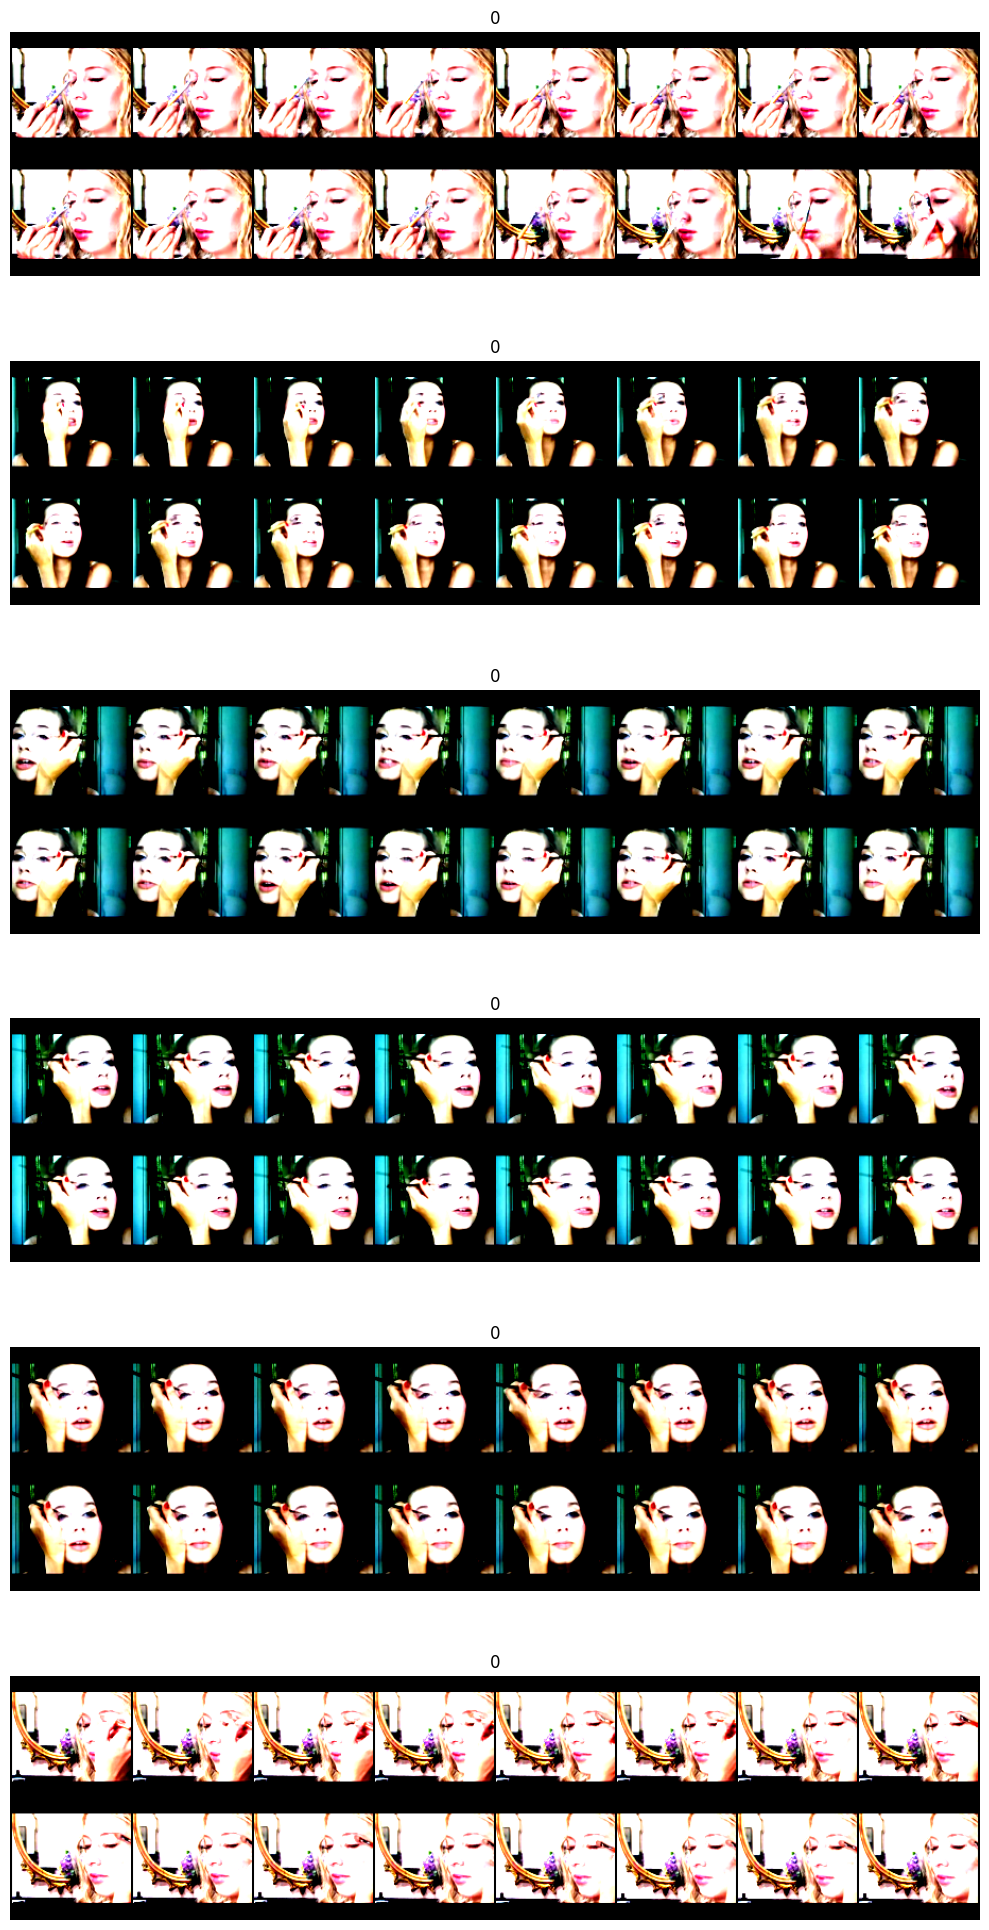

In [6]:
sampled_video_indices=list(range(0,len(videos),4))
_, ax=plt.subplots(len(sampled_video_indices),1, figsize=(10,20))
for i, b in enumerate(sampled_video_indices): 
    label_ids=torch.nonzero(labels[b]>0, as_tuple=True)[0].tolist()
    ax[i].imshow(make_grid(videos[b].permute(1,0,2,3)).permute(1,2,0))
    ax[i].set_title('-'.join([f'{l}' for l in label_ids]), fontsize=12)
    ax[i].axis('off')
plt.tight_layout()

In [7]:
model=torchvision.models.get_model(args.model, weights=None)
model.fc=nn.Linear(in_features=512, out_features=101, bias=True)
initialize_weights(model)
nn.init.normal_(model.fc.weight, mean=0.0, std=0.01) # weights are also initialized to a small Gaussian
nn.init.zeros_(model.fc.bias)
# Below makes the initial softmax output match the dataset distribution before seeing any data.
# but UCF101 is fairly balanced so gains are negligible; and therefore almost no papers bother
# priors = class_counts / class_counts.sum()
# model.fc.bias.data = torch.log(priors)

model.to(device)
if args.distributed and args.sync_bn: model=torch.nn.SyncBatchNorm.convert_sync_batchnorm(model) # only support DDP

criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(), lr=args.lr, momentum=args.momentum, weight_decay=args.weight_decay)
scaler=torch.cuda.amp.GradScaler() if (args.device=='cuda' and args.amp) else None

# Convert scheduler to be per iteration, not per epoch, for warmup that lasts between different epochs
iters_per_epoch=len(train_loader)
lr_milestones=[iters_per_epoch*(m-args.lr_warmup_epochs) for m in args.lr_milestones]
main_lr_scheduler=torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=lr_milestones, gamma=args.lr_gamma)

if args.lr_warmup_epochs>0:
    warmup_iters=iters_per_epoch*args.lr_warmup_epochs
    args.lr_warmup_method=args.lr_warmup_method.lower()
    if args.lr_warmup_method=='linear':
        warmup_lr_scheduler=torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=args.lr_warmup_decay, total_iters=warmup_iters)
    elif args.lr_warmup_method=='constant':
        warmup_lr_scheduler=torch.optim.lr_scheduler.ConstantLR(optimizer, factor=args.lr_warmup_decay, total_iters=warmup_iters)
    else: raise RuntimeError(f"Invaid warmup lr method '{args.lr_warmup_method}'. Only linear and constant are supoorted")
    lr_scheduler=torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_lr_scheduler, main_lr_scheduler], milestones=[warmup_iters])
else: lr_scheduler=main_lr_scheduler

model_without_ddp=model
if args.distributed:
    model=torch.nn.parallel.DistributedDataParallel(model, device_ids=[args.gpu])
    model_without_ddp=model.module

args.start_epoch=0
best_acc=-np.inf
if args.resume and (args.checkpoint_dirpath/args.last).is_file():
    checkpoint=torch.load(args.checkpoint_dirpath/args.last, map_location='cpu', weights_only=False)
    model_without_ddp.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    lr_scheduler.load_state_dict(checkpoint['lr_scheduler'])
    args.start_epoch=checkpoint['epoch']+1
    best_acc=checkpoint['best_acc']
    if args.amp: scaler.load_state_dict(checkpoint['scaler'])
    print(f"Resume training from epoch {args.start_epoch} based on checkpoint {args.checkpoint_dirpath/args.last}")

Resume training from epoch 3 based on checkpoint D:\results\ucf101\train\checkpoint\last.pth


In [ ]:
print("Start training")
start_time=time.time()
stop=False
for epoch in range(args.start_epoch, args.epochs):
    start_epoch_time=time.time()
    if args.distributed: train_sampler.set_epoch(epoch)
    train_metric_logger=MetricLogger(delimiter=' ')
    stop|=train_one_epoch(model, criterion, optimizer, lr_scheduler, data_loader=train_loader, device=device, epoch=epoch, 
                          print_freq=args.print_freq, max_time=args.time, start_time=args.start_training_time, 
                          metric_logger=train_metric_logger, n_batches=args.n_batches)
    val_metric_logger=MetricLogger(delimiter=' ')
    acc1=evaluate(model, criterion, data_loader=val_loader, device=device, print_freq=args.print_freq, metric_logger=val_metric_logger,
                 n_batches=args.n_batches, distributed=args.distributed)


    if best_acc<acc1:
        best_acc=acc1
        if args.ouput_path: save_checkpoint(args.checkpoint_dirpath/args.best, model, optimizer, lr_scheduler, epoch, best_acc)
    if args.ouput_path:
        save_checkpoint(args.checkpoint_dirpath/args.last, model_without_ddp, optimizer, lr_scheduler, epoch, best_acc)
        # save training information
        stats=form_stats(train_metric_logger, mode='train')|form_stats(val_metric_logger, mode='val')
        save_metrics(args.ouput_path/"result.csv", stats, epoch=epoch, start_epoch_time=start_epoch_time)
        if args.plot_freq>0 and (epoch+1)%args.plot_freq==0: plot_results(args.ouput_path/"result.csv")
        
    if all(x is not None for x in [args.start_training_time,args.time]):
        stop|=(time.time()-args.start_training_time)>(args.time*3600)
        
    if stop: break
    break
total_time=time.time()-start_time
total_time_str=str(datetime.timedelta(seconds=int(total_time)))
print(f"Training time {total_time_str}")

In [12]:
len(train_loader)

1412